# Initialiser client Boto 3

In [2]:
import os
import io 
import boto3
import json
from pprint import pprint
import pandas as pd
from tqdm.notebook import tqdm  #  Barre Jupyter native (bleue)
# ou : from tqdm.autonotebook import tqdm  # auto console/notebook

import pyarrow.parquet as pq
import pyarrow.json as paj
import pyarrow as pa

from tqdm import tqdm
import time

endpoint = os.environ["S3_ENDPOINT_URL"]
bucket = os.environ["S3_BUCKET"]

s3_boto = boto3.client(
    "s3",
    endpoint_url=endpoint,
    aws_access_key_id=os.environ["S3_ACCESS_KEY"],
    aws_secret_access_key=os.environ["S3_SECRET_KEY"],
    region_name="us-east-1",
)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

# Tools

In [3]:
def read_jsonl_from_s3(s3_client, bucket: str, key: str):
    response = s3_client.get_object(Bucket=bucket, Key=key)
    body = response["Body"].read().decode("utf-8")

    records = []
    for line in body.splitlines():
        if line.strip():
            records.append(json.loads(line))

    return records

def read_jsonl_stream(bucket: str, key: str):
    response = client.get_object(Bucket=bucket, Key=key)
    for line in response["Body"].iter_lines():
        if line:
            yield json.loads(line)

import pyarrow.json as paj
import pyarrow as pa
import io

def read_jsonl_arrow(bucket, key):
    obj = client.get_object(Bucket=bucket, Key=key)
    data = obj["Body"].read()
    table = paj.read_json(io.BytesIO(data))
    return table.to_pandas()

import os
import boto3
import pandas as pd

def get_df_from_s3_jsonl( client, Prefixe):
    
    resp = client.list_objects_v2(
        Bucket=S3_BUCKET,
        Prefix = Prefixe
    )
    
    keys = [obj["Key"] for obj in resp.get("Contents", [])]
    
    dfs = []
    
    for key in keys:
        #print(f"key : {key}")
        if key.endswith(".jsonl"):
            df_part = read_jsonl_arrow(S3_BUCKET, key)
            dfs.append(df_part)
    
    df = pd.concat(dfs, ignore_index=True)
    return df


def list_object_from_key(s3_client, bucket, key, limit=5 ):
    resp = s3_client.list_objects_v2(Bucket=bucket, Prefix=key)
    ret = [obj["Key"] for obj in resp.get("Contents", [])]
    if(limit!=0) :
        return ret[:limit]
    else :
        return ret

def get_all_df_from_s3_jsonl(s3_client, bucket: str, prefix: str = "") -> pd.DataFrame:
    all_records = []
    all_errors = []
    # 1. Liste JSONL
    jsonl_keys = []
    paginator = s3_client.get_paginator('list_objects_v2')
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get('Contents', []):
            if obj['Key'].endswith('.jsonl'):
                jsonl_keys.append(obj['Key'])
    
    if not jsonl_keys:
        print("⚠️ Aucun JSONL")
        return pd.DataFrame()
    
    print(f"📂 {len(jsonl_keys)} JSONL...")
    
    # 2. tqdm.notebook → barre Jupyter !
    pbar = tqdm(jsonl_keys, desc="JSONL", unit="fichiers", 
               bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")
    
    for key in pbar:
        try:
            response = s3_client.get_object(Bucket=bucket, Key=key)
            lines = response['Body'].read().decode('utf-8').splitlines()
            
            n_new = 0
            for line in lines:
                line = line.strip()
                if line:
                    all_records.append(json.loads(line))
                    n_new += 1
            
            pbar.set_postfix({"nouveau": f"{n_new:,}"})
            
        except Exception as e:
            all_errors.append( (f"❌ {key.split('/')[-1]}: {e}") )

    
    # 3. DataFrame
    df = pd.DataFrame(all_records)
    print(f"✓ {len(all_records):,} records | {df.shape}")

    if all_errors:
        print(f"⚠️ {len(all_errors)} erreurs:")
        for err in all_errors[:50]:  # top 50
            print(f"  • {err}")
        if len(all_errors) > 50:
            print(f"  ... et {len(all_errors)-50} autres")
    return df

# Lister des objets Boto3

In [4]:
list_object_from_key( s3_boto, bucket, "france_travail/bronze/",5)

['france_travail/bronze/metadata/runs/run_id=20260213T082635Z/run.json',
 'france_travail/bronze/offers/dt=2026-02-13/run_id=20260213T082635Z/code_rome=A1101/segment=global/part-000001.jsonl',
 'france_travail/bronze/offers/dt=2026-02-13/run_id=20260213T082635Z/code_rome=A1101/segment=global/part-000002.jsonl',
 'france_travail/bronze/offers/dt=2026-02-13/run_id=20260213T082635Z/code_rome=A1101/segment=global/part-000003.jsonl',
 'france_travail/bronze/offers/dt=2026-02-13/run_id=20260213T082635Z/code_rome=A1101/segment=global/part-000004.jsonl']

# Lire un JSONL (bronze) via boto3

In [5]:
key = "france_travail/bronze/offers/dt=2026-02-13/run_id=20260213T082635Z/code_rome=A1101/segment=global/part-000001.jsonl"
df_all_records = get_all_df_from_s3_jsonl(s3_boto, bucket, key) 
print(f"Total records: {len(df_all_records)}")


📂 1 JSONL...


JSONL: 100%|██████████| 1/1 [00:00<00:00]

✓ 150 records | (150, 42)
Total records: 150


# Lire un lot de JSONL (bronze) via boto3

In [6]:
key="france_travail/bronze/offers/"
df_all_records = get_all_df_from_s3_jsonl(s3_boto, bucket, key) 
print(f"Total records: {len(df_all_records)}")


📂 5415 JSONL...


JSONL: 100%|██████████| 5415/5415 [01:48<00:00]


✓ 520,416 records | (520416, 43)
⚠️ 503 erreurs:
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column 1217 (char 1216)
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column 755 (char 754)
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column 984 (char 983)
  • ❌ part-000003.jsonl: Unterminated string starting at: line 1 column 1126 (char 1125)
  • ❌ part-000006.jsonl: Unterminated string starting at: line 1 column 1326 (char 1325)
  • ❌ part-000003.jsonl: Unterminated string starting at: line 1 column 99 (char 98)
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column 4814 (char 4813)
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column 835 (char 834)
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column 1709 (char 1708)
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column 1311 (char 1310)
  • ❌ part-000001.jsonl: Unterminated string starting at: line 1 column

# Chargement du référentiel ROME

In [7]:
df_referential_rome = get_all_df_from_s3_jsonl(s3_boto, bucket, "france_travail/bronze/rome/")
print("Total rows:", len(df_referential_rome))
df_referential_rome.head()


📂 1 JSONL...


JSONL: 100%|██████████| 1/1 [00:00<00:00]

✓ 1,584 records | (1584, 2)
Total rows: 1584


,code,libelle
0,A1101,Conducteur / Conductrice de tracteur enjambeur
1,A1102,Débardeur forestier / Débardeuse forestière
2,A1201,Homme / Femme de pied
3,A1202,Agent / Agente technique de l'environnement (ATE)
4,A1203,Agent / Agente technique (espaces verts)


In [8]:
df_rome_count = df_all_records.groupby("romeCode").size().reset_index(name="n_offres")

df_rome_count = df_rome_count.merge(
    df_referential_rome,
    left_on="romeCode",
    right_on="code",
    how="left"
)

df_rome_count = df_rome_count.drop(columns=["code"])
df_rome_count = df_rome_count[
    ["romeCode", "libelle", "n_offres"]
]
df_rome_count.sort_values("n_offres", ascending=False).head(50)


,romeCode,libelle,n_offres
962,K1304,Employé familial / Employée familiale,11740
914,J1501,Aide-soignant / Aide-soignante en puériculture,9917
919,J1506,Infirmier / Infirmière en Médecine Chirurgie O...,8912
152,C1504,Agent / Agente de location immobilière,8657
1220,M1211,Expert-comptable / Experte-comptable,7794
969,K1311,Assistant / Assistante de vie aux familles,7404
1212,M1203,Agent / Agente comptable d'établissement publi...,7378
772,I1304,Agent / Agente de maintenance en électricité e...,6635
707,H2903,Conducteur / Conductrice de machines d'usinage...,6118
508,G1609,Sushiman / Sushiwoman,5807


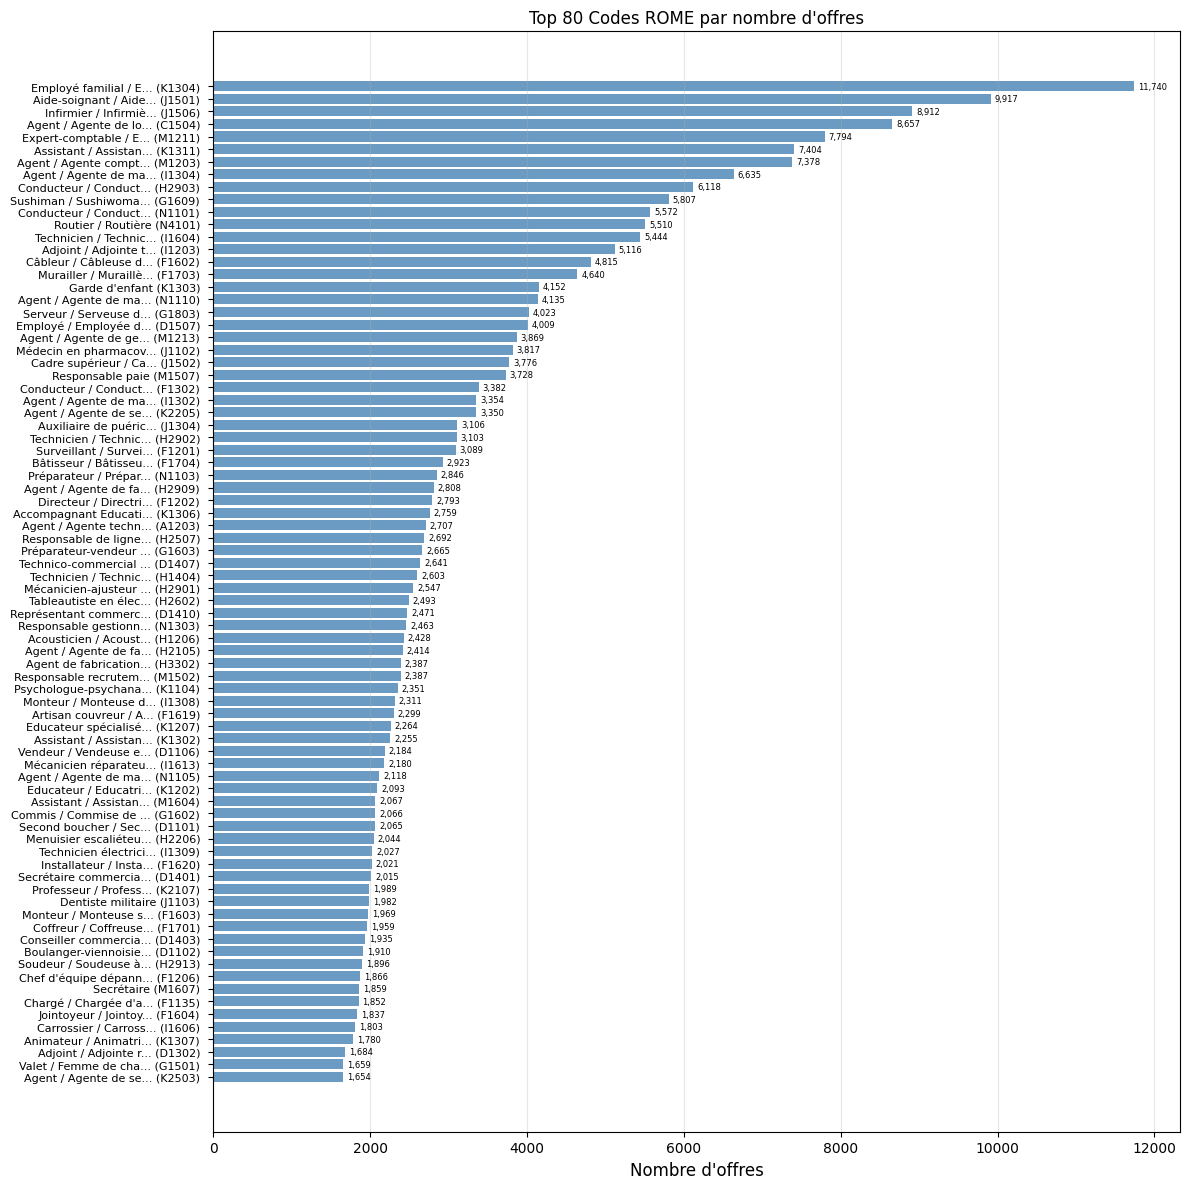

In [47]:
# Top X
def left(s: str, n: int) -> str:
    """Tronque à n caractères"""
    return s[:n] + "..." if len(s) > n else s

top_x_value = 80
top_x = df_rome_count.nlargest(top_x_value, "n_offres")

plt.figure(figsize=(12, 12))
bars = plt.barh(range(len(top_x)), top_x["n_offres"], color='steelblue', alpha=0.8)
plt.yticks(range(len(top_x)), 
           [f"{left(libelle,20)} ({code}) " for code, n, libelle in zip(top_x["romeCode"], top_x["n_offres"], top_x["libelle"] )], fontsize=8) 

plt.xlabel("Nombre d'offres", fontsize=12)
plt.title(f"Top {top_x_value} Codes ROME par nombre d'offres")
plt.gca().invert_yaxis()  # top en haut
plt.grid(axis='x', alpha=0.3)

# Valeurs sur barres
for i, (bar, n) in enumerate(zip(bars, top_x["n_offres"])):
    plt.text(n + 50, i, f'{n:,}', va='center', fontsize=6)

plt.tight_layout()
plt.show()


